The general EDA framework (any dataset)
Step 0 — Frame the problem.
Before touching data: what are you predicting? Is this classification, regression, time series? What would you have at prediction time, and what would you only know after? This determines what counts as leakage.

Step 1 — Structure & granularity.
What does one row represent? What's the key? Are there duplicates? Are the dtypes correct for the meaning of each column?

Step 2 — Target distribution.
Look at the target column's describe(), histogram, boxplot. Is it skewed? Multi-modal? Any impossible values? This decides transformations and metrics.

Step 3 — Missingness.
Inventory the NaN counts. For each column with missing values: is the missingness structural (the value doesn't apply) or unrecorded (it applies but is unknown)? Then decide: impute, drop, keep-as-NaN, or add an indicator.

Step 4 — Categorical columns.
How many categories per column? How balanced? Any ordinal relationships? This decides encoding later.

Step 5 — Numeric columns & outliers.
Distribution of each numeric feature. Are extreme values errors or real signal? Which is which — and why?

Step 6 — Time structure (if there's a date).
What's the date range? Is there trend/seasonality? Does this force a time-based split instead of random?

Step 7 — Relationships between features.
Correlations among numerics. Do any features encode the same thing (redundancy)? Does any feature nearly determine the target (leakage)? Group-level patterns — does the target behave differently across categories?

Step 8 — Leakage audit.
Deliberately scan the feature list for anything that would be unknown at prediction time. This is a separate step from 7 — you're not looking for correlation, you're looking for "when would this value exist in reality?"

Step 9 — Write down the decisions.
Every observation above ends in a decision (keep/drop/transform/impute/split method). Write them down before writing code, so clean.py and preprocess.py implement decisions rather than react to whatever you saw last.

In [2]:
# prerequisites for DS 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler , OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

In [3]:
import sys 
sys.path.append("../src")
from extract import extract_sales_data

(1017209, 18)
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1     

In [4]:
df = extract_sales_data()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [26]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


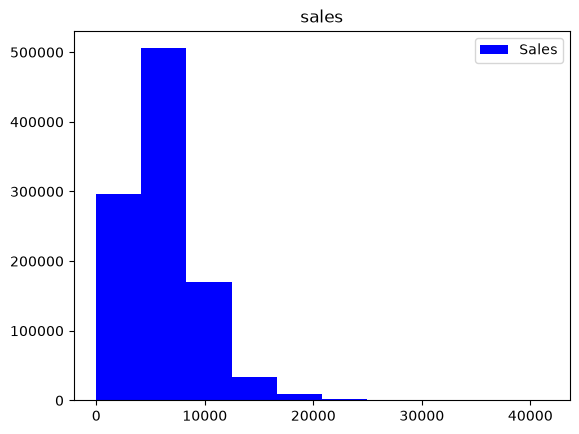

In [11]:
n_bins = 10
fig, ax = plt.subplots()

sales = df['Sales']

ax.hist(sales, n_bins, histtype="barstacked", label="Sales" , color="blue")
ax.legend()
ax.set_title("sales")

plt.show()

Text(0.5, 1.0, 'basic plot')

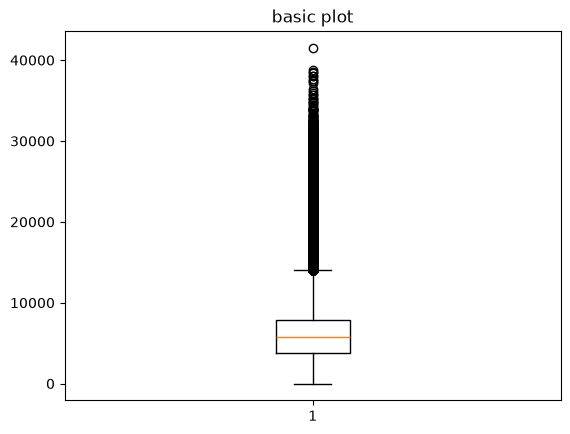

In [18]:
fig, ax = plt.subplots(1, 1)

# basic plot
ax.boxplot(sales)
ax.set_title('basic plot')

In [21]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [27]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [28]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [35]:
df[df["CompetitionDistance"].isna()]["CompetitionOpenSinceMonth"].notna().sum()

np.int64(0)

competitiondistance , competitionyear/month  = a , b 

a.isna , b.isna = 2642  ---> we don't have the distanc nor the competition year/month : simly non existant <--- drop them '


a.notna , b.isna = 320706 ---> we have the distance but not the competition year/month : missing value <--- don't impute them because these nans are facts , impputation will create false information'


a.isna , b.notna = 0  ---> we don't have the distance but we have the competition year/month : impossible scenario


a.notna , b.notna = 693861 ---> we have both the distance and the competition year/month : complete information

In [38]:
df[df['Promo2'] == 0][['Promo2SinceWeek','Promo2SinceYear','PromoInterval']].isna().sum()

Promo2SinceWeek    508031
Promo2SinceYear    508031
PromoInterval      508031
dtype: int64

In [39]:
df[df['Promo2'] == 1][['Promo2SinceWeek','Promo2SinceYear','PromoInterval']].isna().sum()

Promo2SinceWeek    0
Promo2SinceYear    0
PromoInterval      0
dtype: int64

nan values of Promo2SinceWeek, Promo2SinceYear, and PromoInterval are structural , we don't impute them 